In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier 

In [2]:
data = pd.read_csv("Titanic.csv")
data.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
#Analyse et exploration des données
df = data.copy()


In [4]:
df.shape

(891, 16)

<Axes: ylabel='count'>

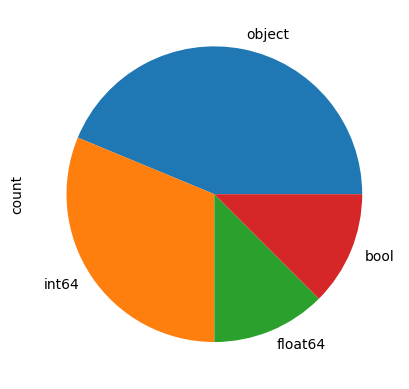

In [5]:
df.dtypes.value_counts().plot.pie()

In [6]:
df.isna()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
(df.isna().sum()/df.shape[0]).sort_values(ascending=True)

Unnamed: 0     0.000000
survived       0.000000
pclass         0.000000
sex            0.000000
sibsp          0.000000
parch          0.000000
fare           0.000000
class          0.000000
who            0.000000
adult_male     0.000000
alive          0.000000
alone          0.000000
embarked       0.002245
embark_town    0.002245
age            0.198653
deck           0.772166
dtype: float64

<Axes: >

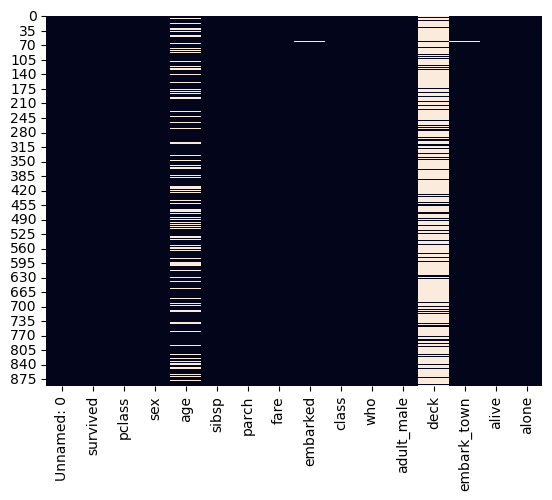

In [8]:
sns.heatmap(df.isna(), cbar=False)

In [9]:
df['survived'].value_counts(normalize=True)

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

<Axes: xlabel='sex', ylabel='count'>

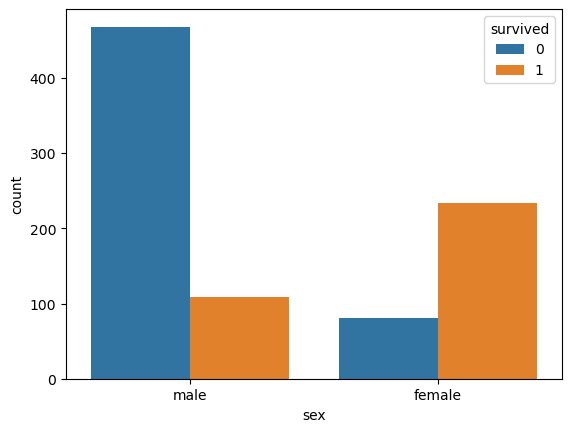

In [10]:
#Relations entre le target et les différentes variables 
sns.countplot(x='sex', hue='survived', data = df)

<Axes: xlabel='pclass', ylabel='count'>

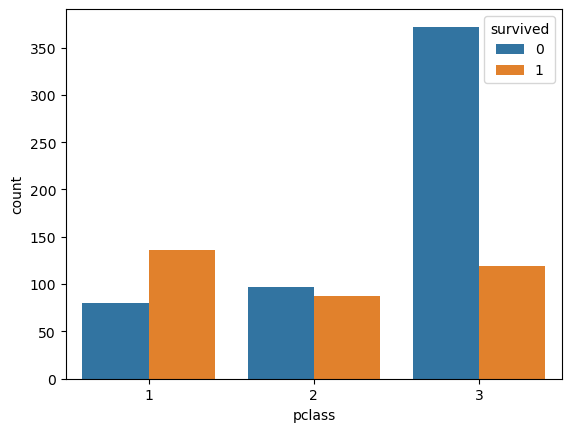

In [11]:
sns.countplot(x='pclass', hue='survived', data = df)

<Axes: xlabel='who', ylabel='count'>

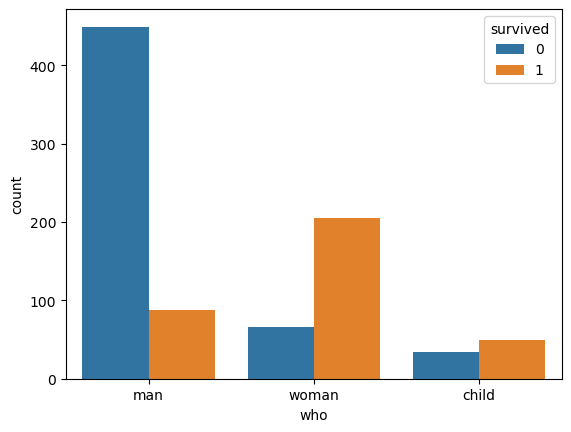

In [12]:
sns.countplot(x='who', hue='survived', data = df)

In [13]:
df['who'].value_counts(normalize=True)

who
man      0.602694
woman    0.304153
child    0.093154
Name: proportion, dtype: float64

In [14]:
df['parch'].value_counts()

parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

In [15]:
df.columns

Index(['Unnamed: 0', 'survived', 'pclass', 'sex', 'age', 'sibsp', 'parch',
       'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='object')

In [16]:
df.drop(['Unnamed: 0', 'class', 'embark_town', 'alive'], axis=1)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,deck,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,NaN,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,C,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,NaN,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,C,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,man,True,NaN,True
887,1,1,female,19.0,0,0,30.0000,S,woman,False,B,True
888,0,3,female,NaN,1,2,23.4500,S,woman,False,NaN,False
889,1,1,male,26.0,0,0,30.0000,C,man,True,C,True


In [17]:
for col in df.select_dtypes("object"):
    print(col, df[col].unique())

sex ['male' 'female']
embarked ['S' 'C' 'Q' nan]
class ['Third' 'First' 'Second']
who ['man' 'woman' 'child']
deck [nan 'C' 'E' 'G' 'D' 'A' 'B' 'F']
embark_town ['Southampton' 'Cherbourg' 'Queenstown' nan]
alive ['no' 'yes']


In [18]:
#Preprocessing
df = data.copy()

In [19]:
df

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [20]:
df = df.drop(['Unnamed: 0', 'class', 'embark_town', 'alive'], axis=1)

In [21]:
df = df.drop(['who'], axis=1)

In [22]:
df['adult_male'] = df['adult_male'].astype(int)
df['alone'] = df['alone'].astype(int)

In [23]:
trainSet, testSet =  train_test_split(df, test_size=0.2, random_state=0)

In [24]:
trainSet

,survived,pclass,sex,age,sibsp,parch,fare,embarked,adult_male,deck,alone
140,0,3,female,NaN,0,2,15.2458,C,0,NaN,0
439,0,2,male,31.0,0,0,10.5000,S,1,NaN,1
817,0,2,male,31.0,1,1,37.0042,C,1,NaN,0
378,0,3,male,20.0,0,0,4.0125,C,1,NaN,1
491,0,3,male,21.0,0,0,7.2500,S,1,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
835,1,1,female,39.0,1,1,83.1583,C,0,E,0
192,1,3,female,19.0,1,0,7.8542,S,0,NaN,0
629,0,3,male,NaN,0,0,7.7333,Q,1,NaN,1
559,1,3,female,36.0,1,0,17.4000,S,0,NaN,0


In [25]:
testSet['survived'].value_counts(normalize=True)

survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64

In [26]:
def encodage(data):
    x = OrdinalEncoder()
    cols = ['sex', 'embarked','deck']
    data[cols] = x.fit_transform(data[cols])
    return data
    

    

In [27]:
def imputation(data):
    data.dropna(axis=0)
    return data


In [28]:
def preprocessing (data):
    data = encodage(data)
    data = imputation(data)

    X = data.drop(['survived'], axis=1)
    y= data['survived']
    print(y.value_counts())

    return X, y

In [29]:
X_train , y_train =  preprocessing(trainSet)

survived
0    439
1    273
Name: count, dtype: int64


In [30]:
X_test, y_test = preprocessing(testSet)

survived
0    110
1     69
Name: count, dtype: int64


In [31]:
#Modelisation
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, f_classif 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [32]:
preprocessor =  make_pipeline(SimpleImputer(strategy='mean'),SelectKBest(f_classif, k=5))

In [33]:
randomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
neighbors = make_pipeline(preprocessor, StandardScaler(),  KNeighborsClassifier())
adaBoost = make_pipeline(preprocessor, StandardScaler(),  AdaBoostClassifier(random_state=0))
svm = make_pipeline(preprocessor, StandardScaler(),  SVC(random_state=0))
XGB = make_pipeline(preprocessor, XGBClassifier(random_state=0))

In [34]:
list_of_models = {
    'randomForest' : randomForest, 
    'neighbors' : neighbors,
    'adaBoost' : adaBoost, 
    'svm' : svm ,
    'XGB' : XGB
}

randomForest
[[95 15]
 [13 56]]
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       110
           1       0.79      0.81      0.80        69

    accuracy                           0.84       179
   macro avg       0.83      0.84      0.84       179
weighted avg       0.84      0.84      0.84       179

neighbors
[[97 13]
 [16 53]]
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       110
           1       0.80      0.77      0.79        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

adaBoost
[[95 15]
 [17 52]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      

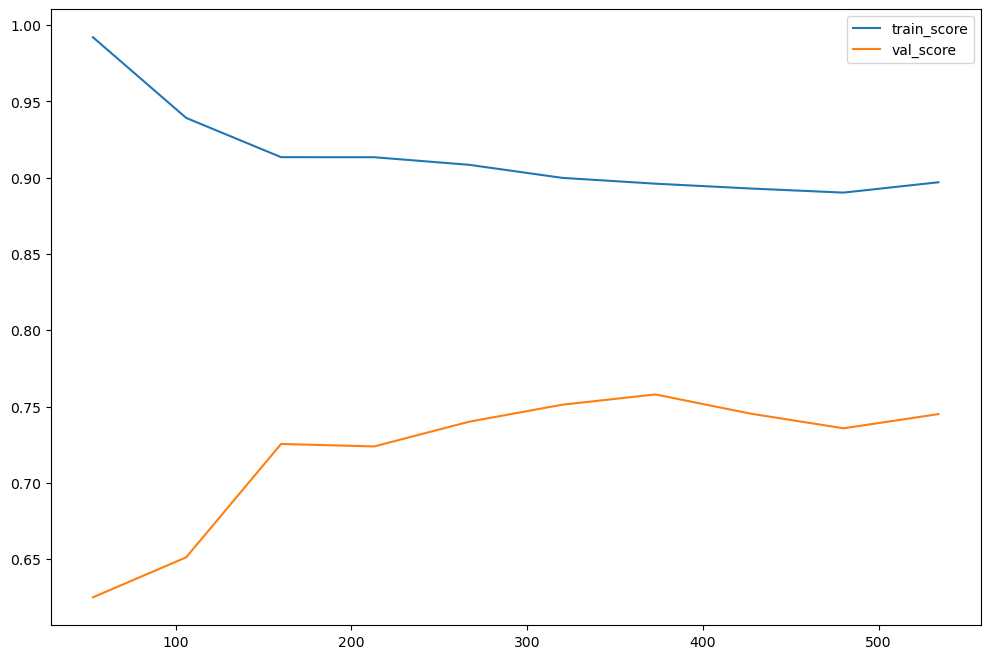

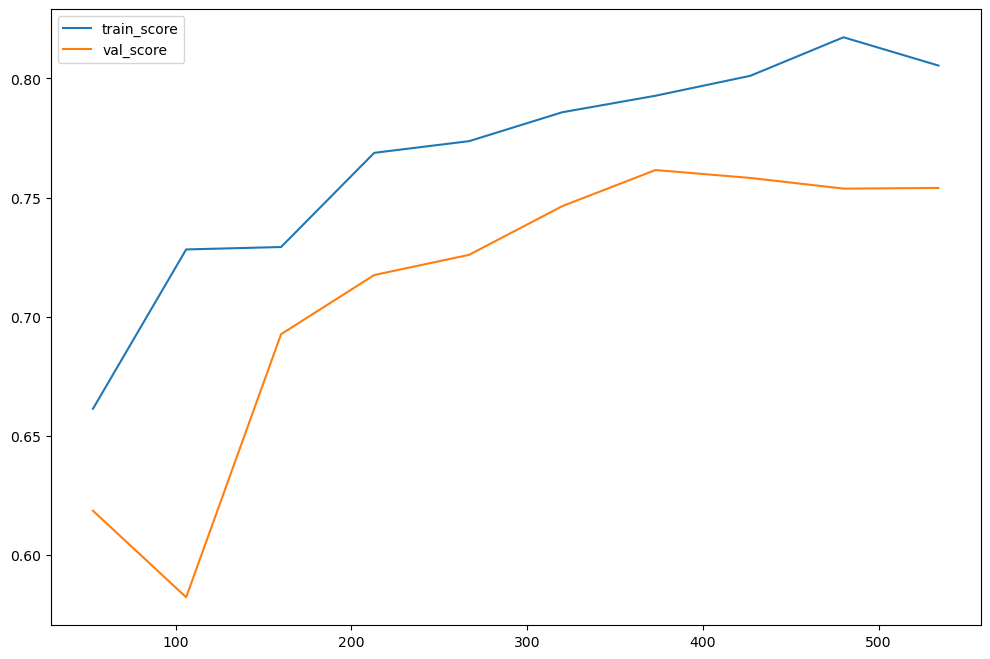

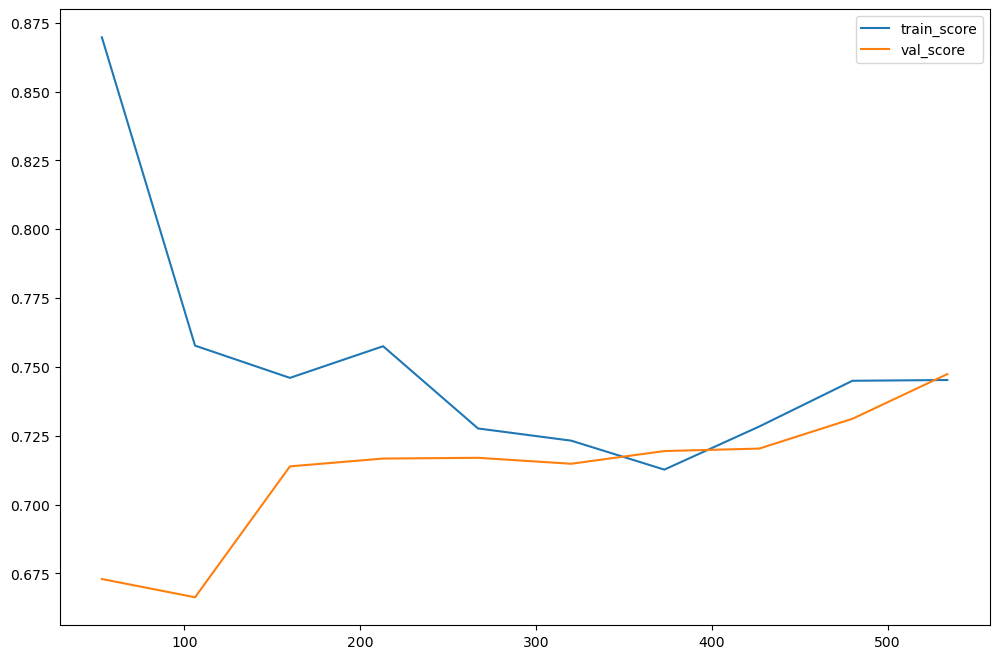

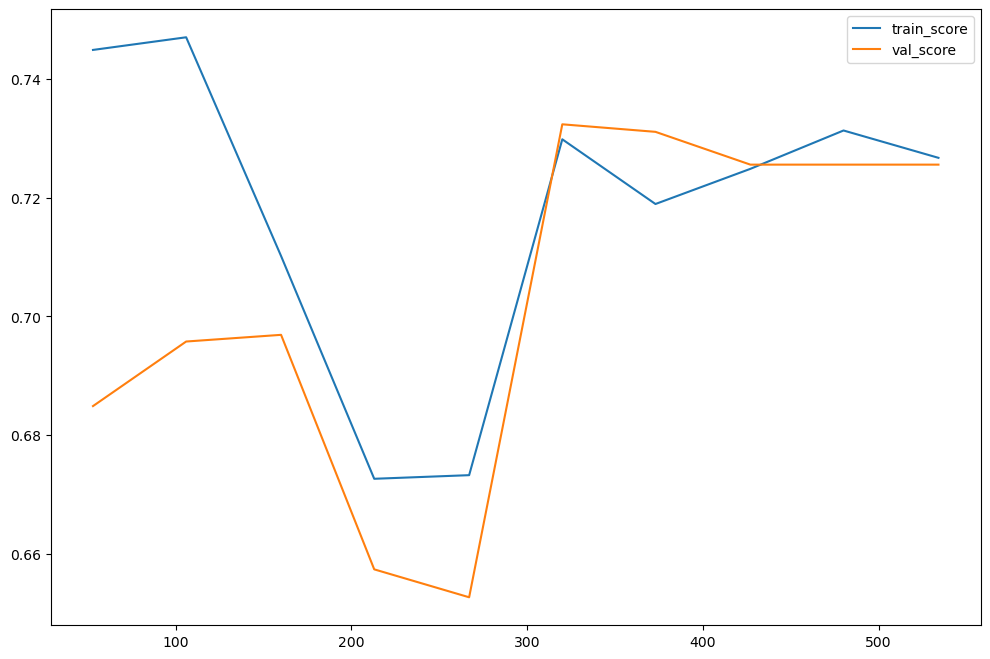

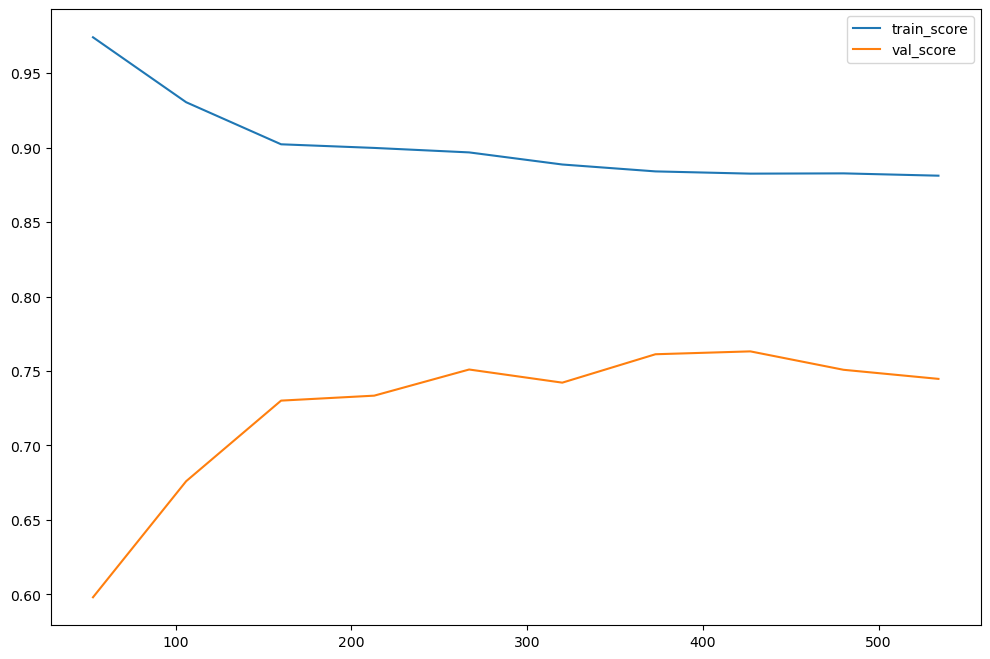

In [37]:
for nom, model in list_of_models.items():
    print(nom)
    evaluation(model)

In [38]:
def evaluation(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred ))
      # Save classification report
    #report = classification_report(y_test, y_pred)
   # with open("classification_report.txt", "w") as f:
      #  f.write(report)

    # Save confusion matrix
    #ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
    #plt.savefig("confusion_matrix.png")
    #plt.close()

    
    

    N, train_score, val_score = learning_curve(model, X_train, y_train, train_sizes=np.linspace(0.1, 1, 10), cv=4, scoring='f1')
    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1), label='train_score')
    plt.plot(N, val_score.mean(axis=1), label='val_score')
    
    plt.legend()
    plt.savefig('learning_curve.png')

In [39]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [40]:
adaBoost

,steps,"[('pipeline', ...), ('standardscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('simpleimputer', ...), ('selectkbest', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None


In [41]:
params = {
    'pipeline__selectkbest__k': range(3, 5),
    'adaboostclassifier__n_estimators': range(50, 75),
  
}

In [42]:
grid = GridSearchCV(adaBoost, params, scoring='recall', cv=4)
grid.fit(X_train, y_train)
print(grid.best_params_)
y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

{'adaboostclassifier__n_estimators': 64, 'pipeline__selectkbest__k': 4}
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



[[95 15]
 [17 52]]
              precision    recall  f1-score   support

           0       0.85      0.86      0.86       110
           1       0.78      0.75      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



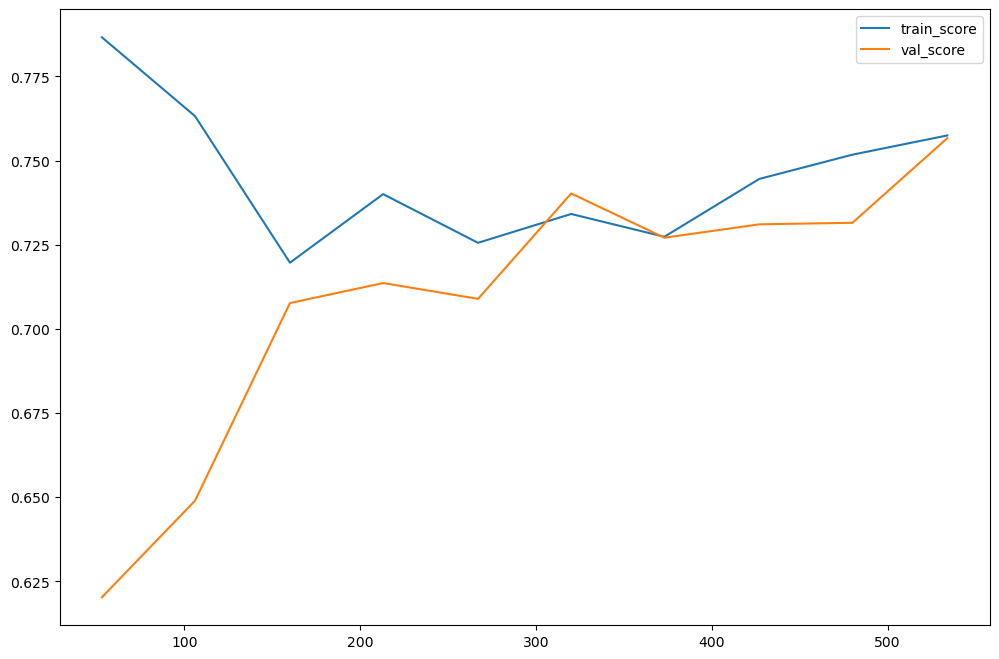

In [43]:
evaluation(grid.best_estimator_)